<h1>10 minutes to pandas</h1>

<p>This is a short introduction to pandas, geared mainly for new users.
You can see more complex recipes in the <a href="cookbook.html#cookbook">Cookbook</a>.</p>

<p>Customarily, we import as follows:</p>

In [1]:
import numpy as np
import pandas as pd

# <h2>Basic data structures in pandas</h2>

<p>Pandas provides two types of classes for handling data:</p>

<ol>
<li><dl>
<dt><a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a>: a one-dimensional labeled array holding data of any type</dt><dd><p>such as integers, strings, Python objects etc.</p>
</dd>
</dl>
</li>
<li><p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a>: a two-dimensional data structure that holds data like
a two-dimension array or a table with rows and columns.</p></li>
</ol>

# <h2>Object creation</h2>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/dsintro.html#dsintro">Intro to data structures section</a>.</p>

<p>Creating a <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> by passing a list of values, letting pandas create a default <a href="https://pandas.pydata.org/docs/reference/api/pandas.RangeIndex.html#pandas.RangeIndex" title="pandas.RangeIndex"><code>RangeIndex</code></a>.</p>

In [2]:
s = pd.Series([1, 3, 5, np.nan, 6, 8])

In [3]:
s

,0
0,1.0
1,3.0
2,5.0
3,NaN
4,6.0
5,8.0


<p>Creating a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> by passing a NumPy array with a datetime index using <a href="https://pandas.pydata.org/docs/reference/api/pandas.date_range.html#pandas.date_range" title="pandas.date_range"><code>date_range()</code></a>
and labeled columns:</p>

In [4]:
dates = pd.date_range("20130101", periods=6)

In [5]:
dates

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [6]:
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list("ABCD"))

In [7]:
df

,A,B,C,D
2013-01-01,0.387369,0.386309,-0.561488,1.284792
2013-01-02,-0.632993,1.178569,-1.763229,0.817245
2013-01-03,-3.157020,-1.087646,0.205582,-0.646860
2013-01-04,0.615450,1.135394,0.040750,0.716604
2013-01-05,0.518734,-0.248176,0.044376,0.384797
2013-01-06,-0.762452,-0.253262,1.909688,0.135675


<p>Creating a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> by passing a dictionary of objects where the keys are the column labels and the values are the column values.</p>

In [8]:
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("20130102"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "foo",
    }
)

In [9]:
df2

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


<p>The columns of the resulting <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> have different
<a href="https://pandas.pydata.org/docs/user_guide/basics.html#basics-dtypes">dtypes</a>:</p>

In [10]:
df2.dtypes

,0
A,float64
B,datetime64[s]
C,float32
D,int32
E,category
F,object


<p>If you’re using IPython, tab completion for column names (as well as public attributes) is automatically enabled.
Here’s a subset of the attributes that will be completed:</p>

<div class="highlight-ipython notranslate"><div class="highlight">
<pre>In [12]: df2<.&lt;TAB&gt;  # noqa: E225, E999
df2.A                  df2.bool
df2.abs                df2.boxplot
df2.add                df2.C
df2.add_prefix         df2.clip
df2.add_suffix         df2.columns
df2.align              df2.copy
df2.all                df2.count
df2.any                df2.combine
df2.append             df2.D
df2.apply              df2.describe
df2.applymap           df2.diff
df2.B                  df2.duplicated
</pre></div></div>

<p>As you can see, the columns <code>A</code>, <code>B</code>, <code>C</code>, and <code>D</code> are automatically tab completed.
<code>E</code> and <code>F</code> are there as well; the rest of the attributes have been truncated for brevity.</p>

# <h2>Viewing data</h2>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/basics.html#basics">Essentially basics functionality section</a>.</p>

<p>Use <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html#pandas.DataFrame.head" title="pandas.DataFrame.head"><code>DataFrame.head()</code></a> and <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.tail.html#pandas.DataFrame.tail" title="pandas.DataFrame.tail"><code>DataFrame.tail()</code></a> to view the top and bottom rows of the frame respectively:</p>

In [11]:
df.head()

,A,B,C,D
2013-01-01,0.387369,0.386309,-0.561488,1.284792
2013-01-02,-0.632993,1.178569,-1.763229,0.817245
2013-01-03,-3.157020,-1.087646,0.205582,-0.646860
2013-01-04,0.615450,1.135394,0.040750,0.716604
2013-01-05,0.518734,-0.248176,0.044376,0.384797


In [12]:
df.tail(3)

,A,B,C,D
2013-01-04,0.615450,1.135394,0.040750,0.716604
2013-01-05,0.518734,-0.248176,0.044376,0.384797
2013-01-06,-0.762452,-0.253262,1.909688,0.135675


<p>Display the <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.index.html#pandas.DataFrame.index" title="pandas.DataFrame.index"><code>DataFrame.index</code></a> or <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html#pandas.DataFrame.columns" title="pandas.DataFrame.columns"><code>DataFrame.columns</code></a>:</p>

In [13]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [14]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

<p>Return a NumPy representation of the underlying data with <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy" title="pandas.DataFrame.to_numpy"><code>DataFrame.to_numpy()</code></a> without the index or column labels:</p>

In [15]:
df.to_numpy()

array([[ 0.3873687 ,  0.38630867, -0.56148797,  1.28479168],
       [-0.63299287,  1.17856895, -1.76322874,  0.81724498],
       [-3.15702042, -1.08764635,  0.20558185, -0.64685977],
       [ 0.61545041,  1.13539408,  0.0407499 ,  0.7166041 ],
       [ 0.51873352, -0.24817618,  0.04437619,  0.38479675],
       [-0.76245214, -0.2532624 ,  1.90968825,  0.13567484]])

<div class="admonition note">
<p class="admonition-title">Note</p>
<p><strong>NumPy arrays have one dtype for the entire array while pandas DataFrames have one dtype per column</strong>.
When you call <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy" title="pandas.DataFrame.to_numpy"><code>DataFrame.to_numpy()</code></a>, pandas will find the NumPy dtype that can hold <em>all</em> of the dtypes in the DataFrame.
If the common data type is <code>object</code>, <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy" title="pandas.DataFrame.to_numpy"><code>DataFrame.to_numpy()</code></a> will require copying data.</p>

In [16]:
df2.dtypes

,0
A,float64
B,datetime64[s]
C,float32
D,int32
E,category
F,object


In [17]:
df2.to_numpy()

array([[1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'train', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'train', 'foo']],
      dtype=object)

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html#pandas.DataFrame.describe" title="pandas.DataFrame.describe"><code>describe()</code></a> shows a quick statistic summary of your data:</p>

In [18]:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,-0.505152,0.185198,-0.020720,0.448709
std,1.429380,0.886600,1.192851,0.664675
min,-3.157020,-1.087646,-1.763229,-0.646860
25%,-0.730087,-0.251991,-0.410929,0.197955
50%,-0.122812,0.069066,0.042563,0.550700
75%,0.485892,0.948123,0.165280,0.792085
max,0.615450,1.178569,1.909688,1.284792


<p>Transposing your data:</p>

In [19]:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,0.387369,-0.632993,-3.157020,0.615450,0.518734,-0.762452
B,0.386309,1.178569,-1.087646,1.135394,-0.248176,-0.253262
C,-0.561488,-1.763229,0.205582,0.040750,0.044376,1.909688
D,1.284792,0.817245,-0.646860,0.716604,0.384797,0.135675


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_index.html#pandas.DataFrame.sort_index" title="pandas.DataFrame.sort_index"><code>DataFrame.sort_index()</code></a> sorts by an axis:</p>

In [20]:
df.sort_index(axis=1, ascending=False)

,D,C,B,A
2013-01-01,1.284792,-0.561488,0.386309,0.387369
2013-01-02,0.817245,-1.763229,1.178569,-0.632993
2013-01-03,-0.646860,0.205582,-1.087646,-3.157020
2013-01-04,0.716604,0.040750,1.135394,0.615450
2013-01-05,0.384797,0.044376,-0.248176,0.518734
2013-01-06,0.135675,1.909688,-0.253262,-0.762452


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html#pandas.DataFrame.sort_values" title="pandas.DataFrame.sort_values"><code>DataFrame.sort_values()</code></a> sorts by values:</p>

In [21]:
df.sort_values(by="B")

,A,B,C,D
2013-01-03,-3.157020,-1.087646,0.205582,-0.646860
2013-01-06,-0.762452,-0.253262,1.909688,0.135675
2013-01-05,0.518734,-0.248176,0.044376,0.384797
2013-01-01,0.387369,0.386309,-0.561488,1.284792
2013-01-04,0.615450,1.135394,0.040750,0.716604
2013-01-02,-0.632993,1.178569,-1.763229,0.817245


# <h2>Selection</h2>

<div class="admonition note">
<p class="admonition-title">Note</p>
<p>While standard Python / NumPy expressions for selecting and setting are intuitive and come in handy for interactive work, for production code, we recommend the optimized pandas data access methods, <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.at.html#pandas.DataFrame.at" title="pandas.DataFrame.at"><code>DataFrame.at()</code></a>, <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iat.html#pandas.DataFrame.iat" title="pandas.DataFrame.iat"><code>DataFrame.iat()</code></a>,
<a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html#pandas.DataFrame.loc" title="pandas.DataFrame.loc"><code>DataFrame.loc()</code></a> and <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html#pandas.DataFrame.iloc" title="pandas.DataFrame.iloc"><code>DataFrame.iloc()</code></a>.</p></div>

<p>See the indexing documentation <a href="https://pandas.pydata.org/docs/user_guide/indexing.html#indexing">Indexing and Selecting Data</a> and <a href="https://pandas.pydata.org/docs/user_guide/advanced.html#advanced">MultiIndex / Advanced Indexing</a>.</p>

## <h3>Getitem (<code>[]</code>)</h3>

<p>For a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a>, passing a single label selects a columns and yields a <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> equivalent to <code>df.A</code>:</p>

In [22]:
df["A"]

,A
2013-01-01,0.387369
2013-01-02,-0.632993
2013-01-03,-3.157020
2013-01-04,0.615450
2013-01-05,0.518734
2013-01-06,-0.762452


<p>For a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a>, passing a slice <code>:</code> selects matching rows:</p>

In [23]:
df[0:3]

,A,B,C,D
2013-01-01,0.387369,0.386309,-0.561488,1.284792
2013-01-02,-0.632993,1.178569,-1.763229,0.817245
2013-01-03,-3.157020,-1.087646,0.205582,-0.646860


In [24]:
df["20130102":"20130104"]

,A,B,C,D
2013-01-02,-0.632993,1.178569,-1.763229,0.817245
2013-01-03,-3.157020,-1.087646,0.205582,-0.646860
2013-01-04,0.615450,1.135394,0.040750,0.716604


## <h3>Selection by label</h3>

<p>See more in <a href="https://pandas.pydata.org/docs/user_guide/indexing.html#indexing-label">Selection by Label</a> using <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html#pandas.DataFrame.loc" title="pandas.DataFrame.loc"><code>DataFrame.loc()</code></a> or <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.at.html#pandas.DataFrame.at" title="pandas.DataFrame.at"><code>DataFrame.at()</code></a>.</p>

<p>Selecting a row matching a label:</p>

In [25]:
df.loc[dates[0]]

,2013-01-01
A,0.387369
B,0.386309
C,-0.561488
D,1.284792


<p>Selecting all rows (<code>:</code>) with a select column labels:</p>

In [26]:
df.loc[:, ["A", "B"]]

,A,B
2013-01-01,0.387369,0.386309
2013-01-02,-0.632993,1.178569
2013-01-03,-3.157020,-1.087646
2013-01-04,0.615450,1.135394
2013-01-05,0.518734,-0.248176
2013-01-06,-0.762452,-0.253262


<p>For label slicing, both endpoints are <em>included</em>:</p>

In [27]:
df.loc["20130102":"20130104", ["A", "B"]]

,A,B
2013-01-02,-0.632993,1.178569
2013-01-03,-3.157020,-1.087646
2013-01-04,0.615450,1.135394


<p>Selecting a single row and column label returns a scalar:</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell19"><span></span><span class="gp">In [30]: </span><span class="n">df</span><span class="o">.</span><span class="n">loc</span><span class="p">[</span><span class="n">dates</span><span class="p">[</span><span class="mi">0</span><span class="p">],</span> <span class="s2">"A"</span><span class="p">]</span>
<span class="gh">Out[30]: </span>0.4691122999071863</span>
</pre>
</div>
</div>

<p>For getting fast access to a scalar (equivalent to the prior method):</p>

<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell20"><span></span><span class="gp">In [31]: </span><span class="n">df</span><span class="o">.</span><span class="n">at</span><span class="p">[</span><span class="n">dates</span><span class="p">[</span><span class="mi">0</span><span class="p">],</span> <span class="s2">"A"</span><span class="p">]</span>
<span class="gh">Out[31]: </span>0.4691122999071863</span>
</pre>
</div>
</div>

## <h3>Selection by position</h3>

<p>See more in <a href="https://pandas.pydata.org/docs/user_guide/indexing.html#indexing-integer">Selection by Position</a> using <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html#pandas.DataFrame.iloc" title="pandas.DataFrame.iloc"><code>DataFrame.iloc()</code></a> or <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iat.html#pandas.DataFrame.iat" title="pandas.DataFrame.iat"><code>DataFrame.iat()</code></a>.</p>

<p>Select via the position of the passed integers:</p>

In [28]:
df.iloc[3]

,2013-01-04
A,0.615450
B,1.135394
C,0.040750
D,0.716604


<p>Integer slices acts similar to NumPy/Python:</p>

In [29]:
df.iloc[3:5, 0:2]

,A,B
2013-01-04,0.615450,1.135394
2013-01-05,0.518734,-0.248176


<p>Lists of integer position locations:</p>

In [30]:
df.iloc[[1, 2, 4], [0, 2]]

,A,C
2013-01-02,-0.632993,-1.763229
2013-01-03,-3.157020,0.205582
2013-01-05,0.518734,0.044376


<p>For slicing rows explicitly:</p>

In [31]:
df.iloc[1:3, :]

,A,B,C,D
2013-01-02,-0.632993,1.178569,-1.763229,0.817245
2013-01-03,-3.157020,-1.087646,0.205582,-0.646860


<p>For slicing columns explicitly:</p>

In [32]:
df.iloc[:, 1:3]

,B,C
2013-01-01,0.386309,-0.561488
2013-01-02,1.178569,-1.763229
2013-01-03,-1.087646,0.205582
2013-01-04,1.135394,0.040750
2013-01-05,-0.248176,0.044376
2013-01-06,-0.253262,1.909688


<p>For getting a value explicitly:</p>

In [33]:
df.iloc[1, 1]

np.float64(1.178568950956558)

<p>For getting fast access to a scalar (equivalent to the prior method):</p>

In [34]:
df.iat[1, 1]

np.float64(1.178568950956558)

## <h3>Boolean indexing</h3>

<p>Select rows where <code>df.A</code> is greater than <code>0</code>.</p>

In [35]:
df[df["A"] > 0]

,A,B,C,D
2013-01-01,0.387369,0.386309,-0.561488,1.284792
2013-01-04,0.615450,1.135394,0.040750,0.716604
2013-01-05,0.518734,-0.248176,0.044376,0.384797


<p>Selecting values from a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> where a boolean condition is met:</p>

In [36]:
df[df > 0]

,A,B,C,D
2013-01-01,0.387369,0.386309,NaN,1.284792
2013-01-02,NaN,1.178569,NaN,0.817245
2013-01-03,NaN,NaN,0.205582,NaN
2013-01-04,0.615450,1.135394,0.040750,0.716604
2013-01-05,0.518734,NaN,0.044376,0.384797
2013-01-06,NaN,NaN,1.909688,0.135675


<p>Using <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.isin.html#pandas.Series.isin" title="pandas.Series.isin"><code>isin()</code></a> method for filtering:</p>

In [37]:
df2 = df.copy()

In [38]:
df2["E"] = ["one", "one", "two", "three", "four", "three"]

In [39]:
df2

,A,B,C,D,E
2013-01-01,0.387369,0.386309,-0.561488,1.284792,one
2013-01-02,-0.632993,1.178569,-1.763229,0.817245,one
2013-01-03,-3.157020,-1.087646,0.205582,-0.646860,two
2013-01-04,0.615450,1.135394,0.040750,0.716604,three
2013-01-05,0.518734,-0.248176,0.044376,0.384797,four
2013-01-06,-0.762452,-0.253262,1.909688,0.135675,three


In [40]:
df2[df2["E"].isin(["two", "four"])]

,A,B,C,D,E
2013-01-03,-3.157020,-1.087646,0.205582,-0.646860,two
2013-01-05,0.518734,-0.248176,0.044376,0.384797,four


## <h3>Setting</h3>

<p>Setting a new column automatically aligns the data by the indexes:</p>

In [41]:
s1 = pd.Series([1, 2, 3, 4, 5, 6], index=pd.date_range("20130102", periods=6))

In [42]:
s1

,0
2013-01-02,1
2013-01-03,2
2013-01-04,3
2013-01-05,4
2013-01-06,5
2013-01-07,6


In [43]:
df["F"] = s1

<p>Setting values by label:</p>

In [44]:
df.at[dates[0], "A"] = 0

<p>Setting values by position:</p>

In [45]:
df.iat[0, 1] = 0

<p>Setting by assigning with a NumPy array:</p>

In [46]:
df.loc[:, "D"] = np.array([5] * len(df))

<p>The result of the prior setting operations:</p>

In [47]:
df

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-0.561488,5.0,NaN
2013-01-02,-0.632993,1.178569,-1.763229,5.0,1.0
2013-01-03,-3.157020,-1.087646,0.205582,5.0,2.0
2013-01-04,0.615450,1.135394,0.040750,5.0,3.0
2013-01-05,0.518734,-0.248176,0.044376,5.0,4.0
2013-01-06,-0.762452,-0.253262,1.909688,5.0,5.0


<p>A <code>where</code> operation with setting:</p>

In [48]:
df2 = df.copy()

In [49]:
df2[df2 > 0] = -df2

In [50]:
df2

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-0.561488,-5.0,NaN
2013-01-02,-0.632993,-1.178569,-1.763229,-5.0,-1.0
2013-01-03,-3.157020,-1.087646,-0.205582,-5.0,-2.0
2013-01-04,-0.615450,-1.135394,-0.040750,-5.0,-3.0
2013-01-05,-0.518734,-0.248176,-0.044376,-5.0,-4.0
2013-01-06,-0.762452,-0.253262,-1.909688,-5.0,-5.0


# <h2>Missing data</h2>

<p>For NumPy data types, <code>np.nan</code> represents missing data. It is by default not included in computations.
See the <a href="https://pandas.pydata.org/docs/user_guide/missing_data.html#missing-data">Missing Data section</a>.</p>

<p>Reindexing allows you to change/add/delete the index on a specified axis. This returns a copy of the data:</p>

In [51]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ["E"])

In [52]:
df1.loc[dates[0] : dates[1], "E"] = 1

In [53]:
df1

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,-0.561488,5.0,NaN,1.0
2013-01-02,-0.632993,1.178569,-1.763229,5.0,1.0,1.0
2013-01-03,-3.157020,-1.087646,0.205582,5.0,2.0,NaN
2013-01-04,0.615450,1.135394,0.040750,5.0,3.0,NaN


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html#pandas.DataFrame.dropna" title="pandas.DataFrame.dropna"><code>DataFrame.dropna()</code></a> drops any rows that have missing data:</p>

In [54]:
df1.dropna(how="any")

,A,B,C,D,F,E
2013-01-02,-0.632993,1.178569,-1.763229,5.0,1.0,1.0


<div class="highlight-ipython notranslate"><div class="highlight"><pre id="codecell38"><span></span><span class="gp">In [58]: </span><span class="n">df1</span><span class="o">.</span><span class="n">dropna</span><span class="p">(</span><span class="n">how</span><span class="o">=</span><span class="s2">"any"</span><span class="p">)</span>
<span class="gh">Out[58]: </span>
                   A         B         C    D    F    E</span>
2013-01-02  1.212112 -0.173215  0.119209  5.0  1.0  1.0</span>
</pre>
</div>
</div>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html#pandas.DataFrame.fillna" title="pandas.DataFrame.fillna"><code>DataFrame.fillna()</code></a> fills missing data:</p>

In [55]:
 df1.fillna(value=5)

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,-0.561488,5.0,5.0,1.0
2013-01-02,-0.632993,1.178569,-1.763229,5.0,1.0,1.0
2013-01-03,-3.157020,-1.087646,0.205582,5.0,2.0,5.0
2013-01-04,0.615450,1.135394,0.040750,5.0,3.0,5.0


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.isna.html#pandas.isna" title="pandas.isna"><code>isna()</code></a> gets the boolean mask where values are <code>nan</code>:</p>

In [56]:
pd.isna(df1)

,A,B,C,D,F,E
2013-01-01,False,False,False,False,True,False
2013-01-02,False,False,False,False,False,False
2013-01-03,False,False,False,False,False,True
2013-01-04,False,False,False,False,False,True


# <h2>Operations</h2>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/basics.html#basics-binop">Basic section on Binary Ops</a>.</p>

## <h3>Stats</h3>

<p>Operations in general <em>exclude</em> missing data.</p>

<p>Calculate the mean value for each column:</p>

In [57]:
df.mean()

,0
A,-0.569714
B,0.120813
C,-0.020720
D,5.000000
F,3.000000


<p>Calculate the mean value for each row:</p>

In [58]:
df.mean(axis=1)

,0
2013-01-01,1.109628
2013-01-02,0.956469
2013-01-03,0.592183
2013-01-04,1.958319
2013-01-05,1.862987
2013-01-06,2.178795


<p>Operating with another <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</span></code></a> or <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> with a different index or column will align the result with the union of the index or column labels.
In addition, pandas automatically broadcasts along the specified dimension and will fill unaligned labels with <code>np.nan</code>.</p>

In [59]:
s = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(2)

In [60]:
s

,0
2013-01-01,NaN
2013-01-02,NaN
2013-01-03,1.0
2013-01-04,3.0
2013-01-05,5.0
2013-01-06,NaN


In [61]:
df.sub(s, axis="index")

,A,B,C,D,F
2013-01-01,NaN,NaN,NaN,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN,NaN
2013-01-03,-4.157020,-2.087646,-0.794418,4.0,1.0
2013-01-04,-2.384550,-1.864606,-2.959250,2.0,0.0
2013-01-05,-4.481266,-5.248176,-4.955624,0.0,-1.0
2013-01-06,NaN,NaN,NaN,NaN,NaN


## <h3>User defined functions</h3>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.agg.html#pandas.DataFrame.agg" title="pandas.DataFrame.agg"><code>DataFrame.agg()</code></a> and <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transform.html#pandas.DataFrame.transform" title="pandas.DataFrame.transform"><code>DataFrame.transform()</code></a> applies a user defined function
that reduces or broadcasts its result respectively.</p>

In [62]:
df.agg(lambda x: np.mean(x) * 5.6)

,0
A,-3.190396
B,0.676553
C,-0.116032
D,28.000000
F,16.800000


In [63]:
df.transform(lambda x: x * 101.2)

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-56.822582,506.0,NaN
2013-01-02,-64.058878,119.271178,-178.438749,506.0,101.2
2013-01-03,-319.490466,-110.069811,20.804883,506.0,202.4
2013-01-04,62.283581,114.901880,4.123890,506.0,303.6
2013-01-05,52.495832,-25.115429,4.490871,506.0,404.8
2013-01-06,-77.160156,-25.630155,193.260450,506.0,506.0


## <h3>Value Counts</h3>

<p>See more at <a href="https://pandas.pydata.org/docs/user_guide/basics.html#basics-discretization">Histogramming and Discretization</a>.</p>

In [64]:
s = pd.Series(np.random.randint(0, 7, size=10))

In [65]:
s

,0
0,2
1,6
2,6
3,2
4,6
5,2
6,4
7,6
8,2
9,5


In [66]:
s.value_counts()

,count
2,4
6,4
4,1
5,1


## <h3>String Methods</h3>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> is equipped with a set of string processing methods in the <code>str</code> attribute that make it easy to operate on each element of the array, as in the code snippet below. See more at <a href="https://pandas.pydata.org/docs/user_guide/text.html#text-string-methods">Vectorized String Methods</a>.</p>

In [67]:
s = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])

In [68]:
s.str.lower()

,0
0,a
1,b
2,c
3,aaba
4,baca
5,NaN
6,caba
7,dog
8,cat


# <h2>Merge</h2>

## <h3>Concat</h3>

<p>pandas provides various facilities for easily combining together <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> and
<a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> objects with various kinds of set logic for the indexes
and relational algebra functionality in the case of join / merge-type
operations.</p>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/merging.html#merging">Merging section</a>.</p>

<p>Concatenating pandas objects together row-wise with <a href="https://pandas.pydata.org/docs/reference/api/pandas.concat.html#pandas.concat" title="pandas.concat"><code>concat()</code></a>:</p>

In [69]:
df = pd.DataFrame(np.random.randn(10, 4))

In [70]:
df

,0,1,2,3
0,-0.333194,-0.539991,-0.145426,-0.424835
1,-1.247171,-0.654964,2.252385,0.196850
2,-1.634207,0.674132,1.347853,-0.481983
3,1.252343,0.790208,0.539688,2.130558
4,-0.546520,-0.447082,-0.037634,2.163235
5,-0.371165,-1.656475,-0.478814,-0.369423
6,0.762950,1.425324,1.201942,-0.041827
7,-0.395525,1.677169,-0.776496,1.069311
8,0.021488,-0.814673,-1.193079,-0.227600
9,-1.313545,1.584281,0.087552,1.375542


In [71]:
# break it into pieces


In [72]:
pieces = [df[:3], df[3:7], df[7:]]

In [73]:
pd.concat(pieces)

,0,1,2,3
0,-0.333194,-0.539991,-0.145426,-0.424835
1,-1.247171,-0.654964,2.252385,0.196850
2,-1.634207,0.674132,1.347853,-0.481983
3,1.252343,0.790208,0.539688,2.130558
4,-0.546520,-0.447082,-0.037634,2.163235
5,-0.371165,-1.656475,-0.478814,-0.369423
6,0.762950,1.425324,1.201942,-0.041827
7,-0.395525,1.677169,-0.776496,1.069311
8,0.021488,-0.814673,-1.193079,-0.227600
9,-1.313545,1.584281,0.087552,1.375542


<div class="admonition note">
<p class="admonition-title">Note</p>
<p>Adding a column to a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> is relatively fast. However, adding a row requires a copy, and may be expensive.
We recommend passing a pre-built list of records to the <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> constructor instead of building a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> by iteratively appending records to it.</p>
</div>

## <h3>Join</h3>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.merge.html#pandas.merge"><code>merge()</code></a> enables SQL style join types along specific columns. See the <a href="https://pandas.pydata.org/docs/user_guide/merging.html#merging-join">Database style joining</a> section.</p>

In [74]:
left = pd.DataFrame({"key": ["foo", "foo"], "lval": [1, 2]})

In [75]:
right = pd.DataFrame({"key": ["foo", "foo"], "rval": [4, 5]})

In [76]:
left

,key,lval
0,foo,1
1,foo,2


In [77]:
right

,key,rval
0,foo,4
1,foo,5


In [78]:
pd.merge(left, right, on="key")

,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.merge.html#pandas.merge" title="pandas.merge"><code>merge()</code></a> on unique keys:</p>

In [79]:
left = pd.DataFrame({"key": ["foo", "bar"], "lval": [1, 2]})

In [80]:
right = pd.DataFrame({"key": ["foo", "bar"], "rval": [4, 5]})

In [81]:
left

,key,lval
0,foo,1
1,bar,2


In [82]:
right

,key,rval
0,foo,4
1,bar,5


In [83]:
pd.merge(left, right, on="key")

,key,lval,rval
0,foo,1,4
1,bar,2,5


# <h2>Grouping</h2>

<p>By “group by” we are referring to a process involving one or more of the following steps:</p>

<ul>
<li><p><strong>Splitting</strong> the data into groups based on some criteria</p></li>
<li><p><strong>Applying</strong> a function to each group independently</p></li>
<li><p><strong>Combining</strong> the results into a data structure</p></li>
</ul>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/groupby.html#groupby">Grouping section</a>.</p>

In [84]:
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)

In [85]:
df

,A,B,C,D
0,foo,one,0.470839,-0.100421
1,bar,one,0.812568,-0.260382
2,foo,two,-0.649941,-0.392511
3,bar,three,-0.459150,1.470404
4,foo,two,-1.169106,-0.128390
5,bar,two,-2.772409,-0.767282
6,foo,one,-1.309970,-1.065970
7,foo,three,0.820744,0.562732


<p>Grouping by a column label, selecting column labels, and then applying the <a href="https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.sum.html#pandas.core.groupby.DataFrameGroupBy.sum" title="pandas.core.groupby.DataFrameGroupBy.sum"><code>DataFrameGroupBy.sum()</code></a> function to the resulting groups:</p>

In [86]:
df.groupby("A")[["C", "D"]].sum()

,C,D
A,,
bar,-2.418991,0.442740
foo,-1.837433,-1.124559


<p>Grouping by multiple columns label forms <a href="https://pandas.pydata.org/docs/reference/api/pandas.MultiIndex.html#pandas.MultiIndex" title="pandas.MultiIndex"><code>MultiIndex</code></a>.</p>

In [87]:
df.groupby(["A", "B"]).sum()

C         D
A   B                        
bar one    0.812568 -0.260382
    three -0.459150  1.470404
    two   -2.772409 -0.767282
foo one   -0.839130 -1.166391
    three  0.820744  0.562732
    two   -1.819047 -0.520900

# <h2>Reshaping</h2>

<p>See the sections on <a href="https://pandas.pydata.org/docs/user_guide/advanced.html#advanced-hierarchical">Hierarchical Indexing</a> and <a href="https://pandas.pydata.org/docs/user_guide/reshaping.html#reshaping-stacking">Reshaping</a>.</p>

## <h3>Stack</h3>

In [88]:
arrays = [
   ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
   ["one", "two", "one", "two", "one", "two", "one", "two"],
]

In [89]:
index = pd.MultiIndex.from_arrays(arrays, names=["first", "second"])

In [90]:
df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=["A", "B"])

In [91]:
df2 = df[:4]

In [92]:
df2

A         B
first second                    
bar   one    -1.603238  0.105435
      two     1.234162 -1.017351
baz   one     0.042418 -0.450112
      two     0.703638 -0.348178

<p>The <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.stack.html#pandas.DataFrame.stack" title="pandas.DataFrame.stack"><code>stack()</code></a> method “compresses” a level in the DataFrame’s
columns:</p>

In [93]:
stacked = df2.stack(future_stack=True)

In [94]:
stacked

first  second   
bar    one     A   -1.603238
               B    0.105435
       two     A    1.234162
               B   -1.017351
baz    one     A    0.042418
               B   -0.450112
       two     A    0.703638
               B   -0.348178
dtype: float64

<p>With a “stacked” DataFrame or Series (having a <a href="https://pandas.pydata.org/docs/reference/api/pandas.MultiIndex.html#pandas.MultiIndex" title="pandas.MultiIndex"><code>MultiIndex</code></a> as the <code>index</code>), the inverse operation of <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.stack.html#pandas.DataFrame.stack" title="pandas.DataFrame.stack"><code>stack()</code></a> is <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html#pandas.DataFrame.unstack" title="pandas.DataFrame.unstack"><code>unstack()</code></a>, which by default unstacks the <strong>last level</strong>:</p>

In [95]:
stacked.unstack()

A         B
first second                    
bar   one    -1.603238  0.105435
      two     1.234162 -1.017351
baz   one     0.042418 -0.450112
      two     0.703638 -0.348178

In [96]:
stacked.unstack(1)

second        one       two
first                      
bar   A -1.603238  1.234162
      B  0.105435 -1.017351
baz   A  0.042418  0.703638
      B -0.450112 -0.348178

In [97]:
stacked.unstack(0)

first          bar       baz
second                      
one    A -1.603238  0.042418
       B  0.105435 -0.450112
two    A  1.234162  0.703638
       B -1.017351 -0.348178

## <h3>Pivot tables</h3>

<p>See the section on <a href="https://pandas.pydata.org/docs/user_guide/reshaping.html#reshaping-pivot">Pivot Tables</a>.</p>

In [98]:
df = pd.DataFrame(
    {
        "A": ["one", "one", "two", "three"] * 3,
        "B": ["A", "B", "C"] * 4,
        "C": ["foo", "foo", "foo", "bar", "bar", "bar"] * 2,
        "D": np.random.randn(12),
        "E": np.random.randn(12),
    }
)

In [99]:
df

,A,B,C,D,E
0,one,A,foo,-0.148048,0.573635
1,one,B,foo,0.804947,-0.435450
2,two,C,foo,-0.705938,-1.088602
3,three,A,bar,1.125064,0.433518
4,one,B,bar,-0.493118,1.545591
5,one,C,bar,-0.466325,0.652140
6,two,A,foo,1.522753,-0.605421
7,three,B,foo,0.460325,0.452432
8,one,C,foo,0.346653,0.868254
9,one,A,bar,0.840790,-0.006506


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html#pandas.pivot_table" title="pandas.pivot_table"><code>pivot_table()</code></a> pivots a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> specifying the <code>values</code>, <code>index</code> and <code>columns</code></p>

In [100]:
pd.pivot_table(df, values="D", index=["A", "B"], columns=["C"])

C             bar       foo
A     B                    
one   A  0.840790 -0.148048
      B -0.493118  0.804947
      C -0.466325  0.346653
three A  1.125064       NaN
      B       NaN  0.460325
      C -0.634715       NaN
two   A       NaN  1.522753
      B  1.557716       NaN
      C       NaN -0.705938

# <h2>Time series</h2>

<p>pandas has simple, powerful, and efficient functionality for performing resampling operations during frequency conversion (e.g., converting secondly data into 5-minutely data).
This is extremely common in, but not limited to, financial applications. See the <a href="https://pandas.pydata.org/docs/user_guide/timeseries.html#timeseries">Time Series section</a>.</p>

In [101]:
rng = pd.date_range("1/1/2012", periods=100, freq="s")

In [102]:
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)

In [103]:
ts.resample("5Min").sum()

,0
2012-01-01,25446


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.tz_localize.html#pandas.Series.tz_localize" title="pandas.Series.tz_localize"><code>Series.tz_localize()</code></a> localizes a time series to a time zone:</p>

In [104]:
rng = pd.date_range("3/6/2012 00:00", periods=5, freq="D")

In [105]:
ts = pd.Series(np.random.randn(len(rng)), rng)

In [106]:
ts

,0
2012-03-06,0.627966
2012-03-07,-0.595526
2012-03-08,-0.018894
2012-03-09,1.044668
2012-03-10,1.141726


In [107]:
ts_utc = ts.tz_localize("UTC")

In [108]:
ts_utc

,0
2012-03-06 00:00:00+00:00,0.627966
2012-03-07 00:00:00+00:00,-0.595526
2012-03-08 00:00:00+00:00,-0.018894
2012-03-09 00:00:00+00:00,1.044668
2012-03-10 00:00:00+00:00,1.141726


<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.tz_convert.html#pandas.Series.tz_convert" title="pandas.Series.tz_convert"><code>Series.tz_convert()</code></a> converts a timezones aware time series to another time zone:</p>

In [109]:
ts_utc.tz_convert("US/Eastern")

,0
2012-03-05 19:00:00-05:00,0.627966
2012-03-06 19:00:00-05:00,-0.595526
2012-03-07 19:00:00-05:00,-0.018894
2012-03-08 19:00:00-05:00,1.044668
2012-03-09 19:00:00-05:00,1.141726


<p>Adding a non-fixed duration (<a href="https://pandas.pydata.org/docs/reference/api/pandas.tseries.offsets.BusinessDay.html#pandas.tseries.offsets.BusinessDay" title="pandas.tseries.offsets.BusinessDay"><code>BusinessDay</code></a>) to a time series:</p>

In [110]:
rng

DatetimeIndex(['2012-03-06', '2012-03-07', '2012-03-08', '2012-03-09',
               '2012-03-10'],
              dtype='datetime64[ns]', freq='D')

In [111]:
rng + pd.offsets.BusinessDay(5)

DatetimeIndex(['2012-03-13', '2012-03-14', '2012-03-15', '2012-03-16',
               '2012-03-16'],
              dtype='datetime64[ns]', freq=None)

# <h2>Categoricals</h2>

<p>pandas can include categorical data in a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a>. For full docs, see the <a href="https://pandas.pydata.org/docs/user_guide/categorical.html#categorical">categorical introduction</span></a> and the <a href="https://pandas.pydata.org/docs/reference/arrays.html#api-arrays-categorical">API documentation</a>.</p>

In [112]:
df = pd.DataFrame(
    {"id": [1, 2, 3, 4, 5, 6], "raw_grade": ["a", "b", "b", "a", "a", "e"]}
)

<p>Converting the raw grades to a categorical data type:</p>

In [113]:
df["grade"] = df["raw_grade"].astype("category")

In [114]:
df["grade"]

,grade
0,a
1,b
2,b
3,a
4,a
5,e


<p>Rename the categories to more meaningful names:</p>

In [115]:
new_categories = ["very good", "good", "very bad"]

In [116]:
df["grade"] = df["grade"].cat.rename_categories(new_categories)

<p>Reorder the categories and simultaneously add the missing categories (methods under <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.html#pandas.Series.cat" title="pandas.Series.cat"><code>Series.cat()</code></a> return a new <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> by default):</p>

In [117]:
df["grade"] = df["grade"].cat.set_categories(
    ["very bad", "bad", "medium", "good", "very good"]
)

In [118]:
df["grade"]

,grade
0,very good
1,good
2,good
3,very good
4,very good
5,very bad


<p>Sorting is per order in the categories, not lexical order:</p>

In [119]:
df.sort_values(by="grade")

,id,raw_grade,grade
5,6,e,very bad
1,2,b,good
2,3,b,good
0,1,a,very good
3,4,a,very good
4,5,a,very good


<p>Grouping by a categorical column with <code>observed=False</code> also shows empty categories:</p>

In [127]:
df.groupby("grade", observed=False).size()

,0
grade,
very bad,1
bad,0
medium,0
good,2
very good,3


# <h2>Plotting</h2>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/visualization.html#visualization">Plotting</a> docs.</p>

<p>We use the standard convention for referencing the matplotlib API:</p>

In [120]:
import matplotlib.pyplot as plt

plt.close("all")

<p>The <code>plt.close</code> method is used to <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.close.html">close</a> a figure window:</p>

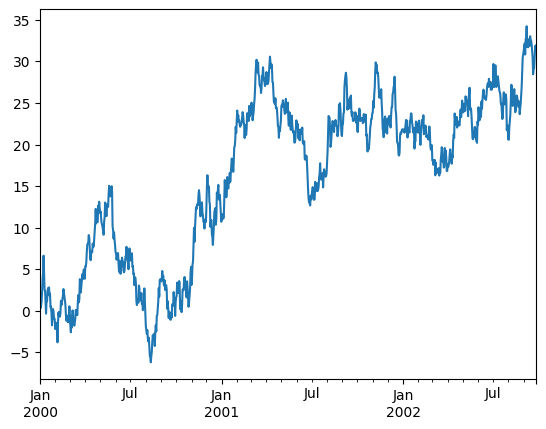

In [121]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))

ts = ts.cumsum()

ts.plot();

<div class="admonition note">
<p class="admonition-title">Note</p>
<p>When using Jupyter, the plot will appear using <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html#pandas.Series.plot" title="pandas.Series.plot"><code>plot()</code></a>.  Otherwise use <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html">matplotlib.pyplot.show</a> to show it or
<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html">matplotlib.pyplot.savefig</a> to write it to a file.</p>
</div>

<p><a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html#pandas.DataFrame.plot" title="pandas.DataFrame.plot"><code>plot()</code></a> plots all columns:</p>

In [134]:
df = pd.DataFrame(
    np.random.randn(1000, 4), index=ts.index, columns=["A", "B", "C", "D"]
)

In [138]:
df = df.cumsum()

<Figure size 640x480 with 0 Axes>

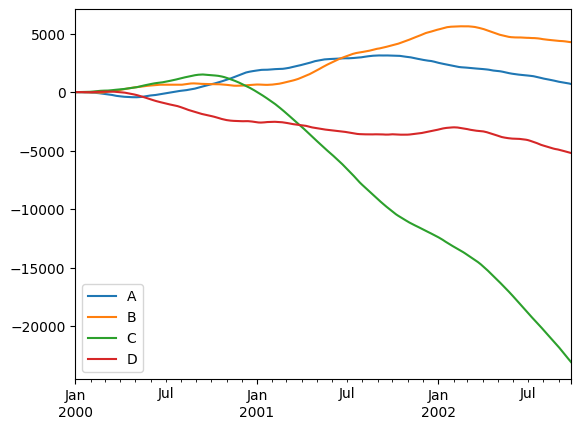

In [141]:
plt.figure()

df.plot()

plt.legend(loc='best')

# <h2>Importing and exporting data</h2>

<p>See the <a href="https://pandas.pydata.org/docs/user_guide/io.html#io">IO Tools</a> section.</p>

## <h3>CSV</h3>

<p><a href="https://pandas.pydata.org/docs/user_guide/io.html#io-store-in-csv">Writing to a csv file:</a> using <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html#pandas.DataFrame.to_csv" title="pandas.DataFrame.to_csv"><code>DataFrame.to_csv()</code></a></p>

In [142]:
df = pd.DataFrame(np.random.randint(0, 5, (10, 5)))

In [143]:
df.to_csv("foo.csv")

<p><a href="https://pandas.pydata.org/docs/user_guide/io.html#io-read-csv-table">Reading from a csv file:></a> using <a href="https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html#pandas.read_csv" title="pandas.read_csv"><code>read_csv()</code></a></p>

In [144]:
pd.read_csv("foo.csv")

,Unnamed: 0,0,1,2,3,4
0,0,1,2,4,1,2
1,1,2,1,1,2,2
2,2,0,3,2,1,3
3,3,2,1,3,0,4
4,4,4,2,3,3,1
5,5,2,1,0,2,1
6,6,1,1,1,2,1
7,7,3,1,0,3,2
8,8,3,4,1,2,2
9,9,0,3,4,3,0


## <h3>Parquet</h3>

<p>Writing to a Parquet file:</p>

In [145]:
df.to_parquet("foo.parquet")

<p>Reading from a Parquet file Store using <a href="https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html#pandas.read_parquet" title="pandas.read_parquet"><code>read_parquet()</code></a>:</p>

In [146]:
pd.read_parquet("foo.parquet")

,0,1,2,3,4
0,1,2,4,1,2
1,2,1,1,2,2
2,0,3,2,1,3
3,2,1,3,0,4
4,4,2,3,3,1
5,2,1,0,2,1
6,1,1,1,2,1
7,3,1,0,3,2
8,3,4,1,2,2
9,0,3,4,3,0


## <h3>Excel</h3>

<p>Reading and writing to <a href="https://pandas.pydata.org/docs/user_guide/io.html#io-excel">Excel</span></a>.</p>

<p>Writing to an excel file using <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_excel.html#pandas.DataFrame.to_excel" title="pandas.DataFrame.to_excel"><code>DataFrame.to_excel()</code></a>:</p>

In [147]:
df.to_excel("foo.xlsx", sheet_name="Sheet1")

<p>Reading from an excel file using <a href="https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html#pandas.read_excel" title="pandas.read_excel"><code>read_excel()</code></a>:</p>

In [148]:
pd.read_excel("foo.xlsx", "Sheet1", index_col=None, na_values=["NA"])

,Unnamed: 0,0,1,2,3,4
0,0,1,2,4,1,2
1,1,2,1,1,2,2
2,2,0,3,2,1,3
3,3,2,1,3,0,4
4,4,4,2,3,3,1
5,5,2,1,0,2,1
6,6,1,1,1,2,1
7,7,3,1,0,3,2
8,8,3,4,1,2,2
9,9,0,3,4,3,0


# <h2>Gotchas</h2>

<p>If you are attempting to perform a boolean operation on a <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series"><code>Series</code></a> or <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame" title="pandas.DataFrame"><code>DataFrame</code></a> you might see an exception like:</p>

In [149]:
if pd.Series([False, True, False]):
     print("I was true")

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

<p>See <a href="https://pandas.pydata.org/docs/user_guide/basics.html#basics-compare">Comparisons</a> and <a href="https://pandas.pydata.org/docs/user_guide/gotchas.html#gotchas">Gotchas</a> for an explanation and what to do.</p>